In [ ]:
import os, glob

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
!pip install -q keras

In [ ]:
import keras

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
from tensorflow.keras.callbacks import Callback,EarlyStopping

In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
from sklearn.metrics import  classification_report

In [ ]:
import os, glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import Callback,EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import  classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train'

In [ ]:
name_class = os.listdir(file_path)
name_class

['benign', 'malignant']

In [ ]:
filepaths = list(glob.glob(file_path+'/**/*.*'))

In [ ]:
filepaths

['/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1014.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/102.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1020.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1016.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1015.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1012.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1011.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1010.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1017.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1009.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1008.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/1005.jpg',
 '/content/drive/MyDrive/Cancer detection/archive (2)/train/benig

In [ ]:
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
labels

['benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',
 'benign',

In [ ]:
filepath = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
data.head(5)

,Filepath,Label
0,/content/drive/MyDrive/Cancer detection/archiv...,malignant
1,/content/drive/MyDrive/Cancer detection/archiv...,malignant
2,/content/drive/MyDrive/Cancer detection/archiv...,malignant
3,/content/drive/MyDrive/Cancer detection/archiv...,benign
4,/content/drive/MyDrive/Cancer detection/archiv...,benign


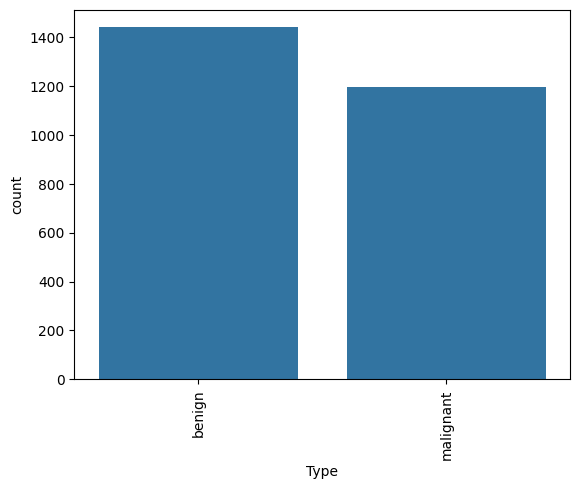

In [ ]:
counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90);

In [ ]:
train, test = train_test_split(data, test_size=0.25, random_state=42)

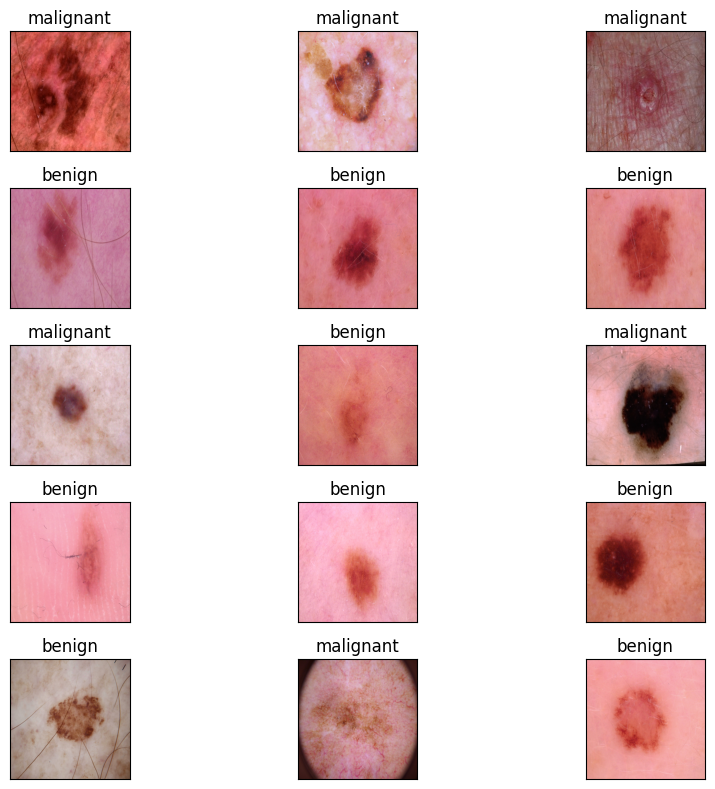

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10,8), subplot_kw={'xticks':[],'yticks':[]})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(100,100),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_gen = train_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(100,100),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(100,100),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 1977 validated image filenames belonging to 2 classes.
Found 660 validated image filenames belonging to 2 classes.
Found 660 validated image filenames belonging to 2 classes.


In [ ]:
##slow working epochs bcoz of gpu so stopped in middle of running at 25 epochs
pretrained_model = ResNet50(
    input_shape=(100,100, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

In [ ]:
inputs = pretrained_model.input

x = Dense(128, activation='relu')(pretrained_model.output)
x = Dense(128, activation='relu')(x)

outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
my_callbacks  = [EarlyStopping(monitor='val_accuracy',
                              min_delta=0,
                              patience=2,
                              mode='auto')]

In [ ]:
##100 epochs taking time so stopped it
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=100
)

Epoch 1/100
62/62 [==============================] - 964s 15s/step - loss: 0.4396 - accuracy: 0.8007 - val_loss: 0.4316 - val_accuracy: 0.8030
Epoch 2/100
62/62 [==============================] - 141s 2s/step - loss: 0.3136 - accuracy: 0.8528 - val_loss: 0.3764 - val_accuracy: 0.8364
Epoch 3/100
62/62 [==============================] - 136s 2s/step - loss: 0.2322 - accuracy: 0.9044 - val_loss: 0.4037 - val_accuracy: 0.8348
Epoch 4/100
62/62 [==============================] - 135s 2s/step - loss: 0.1839 - accuracy: 0.9221 - val_loss: 0.4293 - val_accuracy: 0.8348
Epoch 5/100
62/62 [==============================] - 144s 2s/step - loss: 0.1850 - accuracy: 0.9140 - val_loss: 0.4689 - val_accuracy: 0.8258
Epoch 6/100
62/62 [==============================] - 138s 2s/step - loss: 0.1403 - accuracy: 0.9418 - val_loss: 0.4923 - val_accuracy: 0.8364
Epoch 7/100
62/62 [==============================] - 145s 2s/step - loss: 0.1218 - accuracy: 0.9509 - val_loss: 0.5133 - val_accuracy: 0.8212
Epoch

KeyboardInterrupt: 

In [ ]:
## Better acuracy and decrease the loss

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
inputs = pretrained_model.input
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(pretrained_model.output)
x = Dropout(0.5)(x)  # Dropout added
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)  # Dropout added

outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
my_callbacks = [
    EarlyStopping(
        monitor='val_loss',  # Monitor validation loss instead of accuracy
        min_delta=0,
        patience=5,  # Increase patience to give the model more time
        mode='auto',
        restore_best_weights=True  # Restore the best weights at the end of training
    )
]

# Train the model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=100,
    callbacks=my_callbacks
)



Epoch 1/100
62/62 [==============================] - 152s 2s/step - loss: 0.9686 - accuracy: 0.7284 - val_loss: 0.7272 - val_accuracy: 0.8015
Epoch 2/100
19/62 [========>.....................] - ETA: 1:19 - loss: 0.7228 - accuracy: 0.7961

KeyboardInterrupt: 

In [ ]:
## speed up epochs with 10 epoches

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Define the model
inputs = pretrained_model.input
x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(pretrained_model.output)  # Reduced units
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)  # Reduced units
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
my_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=5,
        mode='auto',
        restore_best_weights=True
    )
]

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Train the model with increased batch size
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10,
    callbacks=my_callbacks,
    batch_size=64  # Increased batch size
)


Epoch 1/10
62/62 [==============================] - 156s 2s/step - loss: 0.9518 - accuracy: 0.7021 - val_loss: 0.7421 - val_accuracy: 0.7970
Epoch 2/10
62/62 [==============================] - 151s 2s/step - loss: 0.7281 - accuracy: 0.7896 - val_loss: 0.6737 - val_accuracy: 0.8152
Epoch 3/10
62/62 [==============================] - 144s 2s/step - loss: 0.6608 - accuracy: 0.8063 - val_loss: 0.5981 - val_accuracy: 0.7939
Epoch 4/10
62/62 [==============================] - 141s 2s/step - loss: 0.5868 - accuracy: 0.8306 - val_loss: 0.5698 - val_accuracy: 0.8273
Epoch 5/10
62/62 [==============================] - 144s 2s/step - loss: 0.5827 - accuracy: 0.8139 - val_loss: 0.5756 - val_accuracy: 0.8348
Epoch 6/10
62/62 [==============================] - 138s 2s/step - loss: 0.5357 - accuracy: 0.8346 - val_loss: 0.5646 - val_accuracy: 0.8318
Epoch 7/10
62/62 [==============================] - 144s 2s/step - loss: 0.5042 - accuracy: 0.8462 - val_loss: 0.5864 - val_accuracy: 0.8288
Epoch 8/10
62

In [ ]:
# Assuming train_gen and valid_gen are Keras ImageDataGenerators
train_ds = tf.data.Dataset.from_generator(lambda: train_gen, output_types=(tf.float32, tf.float32))
valid_ds = tf.data.Dataset.from_generator(lambda: valid_gen, output_types=(tf.float32, tf.float32))

# Prefetch data to improve speed
train_ds = train_ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Train the model with efficient data pipeline
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=100,
    callbacks=my_callbacks,
    batch_size=64
)


Epoch 1/100
      2/Unknown - 8s 1s/step - loss: 0.4036 - accuracy: 0.8906

KeyboardInterrupt: 

In [ ]:
##Ensure GPU Usage:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


Num GPUs Available:  0


In [ ]:
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)


In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

# Set the policy for mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Verify the global policy
print("Global policy:", mixed_precision.global_policy())

# Example model definition (replace with your own model)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Dummy data for demonstration
import numpy as np
x_train = np.random.rand(100, 224, 224, 3)
y_train = np.random.randint(0, 10, size=(100,))

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32)

# Optionally, print model summary
print(model.summary())


TensorFlow version: 2.15.0
Global policy: <Policy "mixed_float16">
Epoch 1/5
4/4 [==============================] - 41s 9s/step - loss: 52.7669 - accuracy: 0.1300
Epoch 2/5
4/4 [==============================] - 42s 9s/step - loss: 113.6400 - accuracy: 0.1200
Epoch 3/5
4/4 [==============================] - 39s 9s/step - loss: 101.4275 - accuracy: 0.1900
Epoch 4/5
4/4 [==============================] - 44s 10s/step - loss: 58.4500 - accuracy: 0.1000
Epoch 5/5
4/4 [==============================] - 42s 9s/step - loss: 50.7363 - accuracy: 0.1400
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                  

In [ ]:
from tensorflow.keras.layers import BatchNormalization

x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(pretrained_model.output)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)


In [ ]:
model.save("model_resnet50.h5")

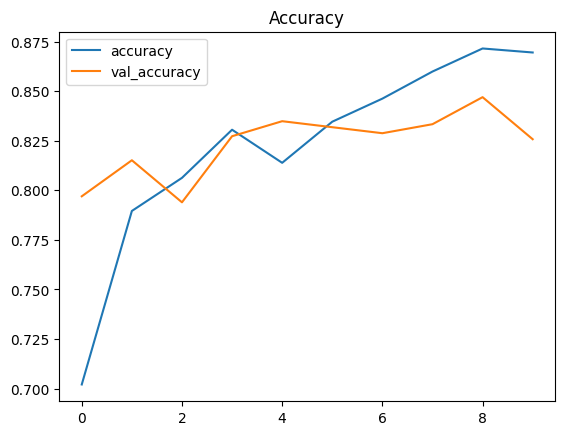

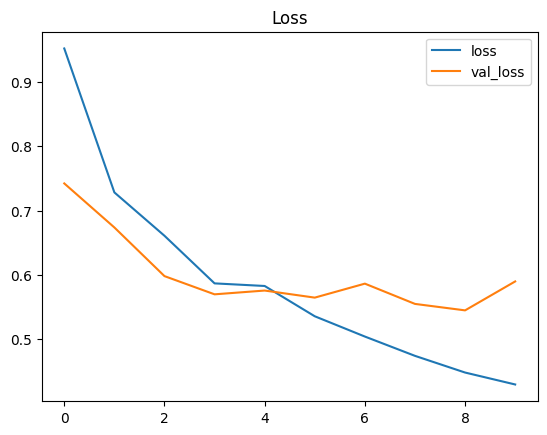

In [ ]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

In [ ]:
results = model.evaluate(test_gen, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.61602
Test Accuracy: 82.73%


In [ ]:
# Predict the label of the test_gen
pred = model.predict(test_gen)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_gen.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

21/21 [==============================] - 34s 2s/step


In [ ]:
y_test = list(test.Label)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      benign       0.79      0.94      0.86       360
   malignant       0.90      0.69      0.78       300

    accuracy                           0.83       660
   macro avg       0.85      0.82      0.82       660
weighted avg       0.84      0.83      0.82       660



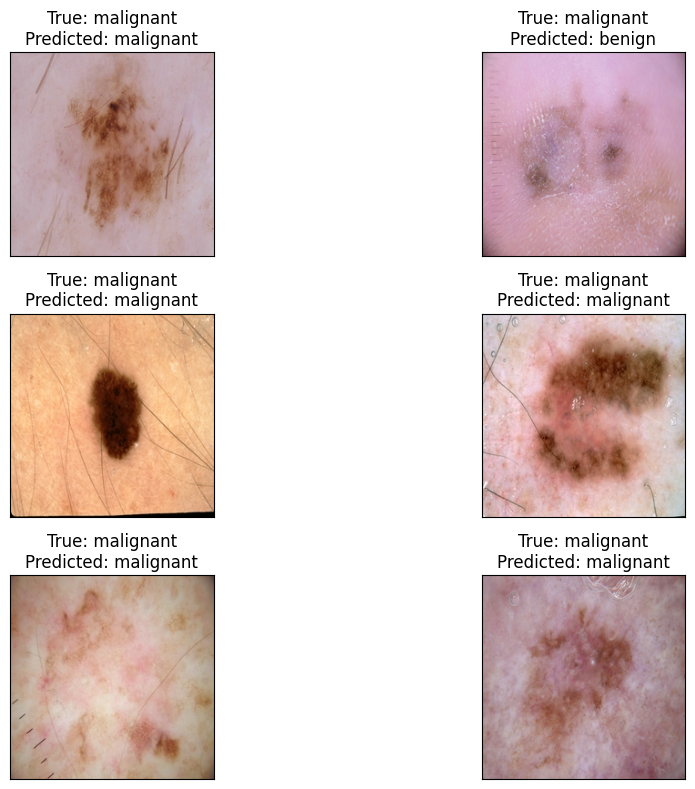

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test.Filepath.iloc[i]))
    ax.set_title(f"True: {test.Label.iloc[i]}\nPredicted: {pred[i]}")
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input

img_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/100.jpg'

#img = image.load_img(img_path, target_size=(224, 224))
#x = img.img_to_array(img)

img = cv2.imread(img_path)
img = cv2.resize(img, (100, 100))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)
result = model.predict(x)
print((result*100).astype('int'))

#print('Input image shape:', x.shape)

#my_image = imread(img_path)
#imshow(my_image)


1/1 [==============================] - 2s 2s/step
[[99  0]]


Loading image from: /content/drive/MyDrive/Cancer detection/archive (2)/train/benign/100.jpg
1/1 [==============================] - 0s 90ms/step
[[99  0]]


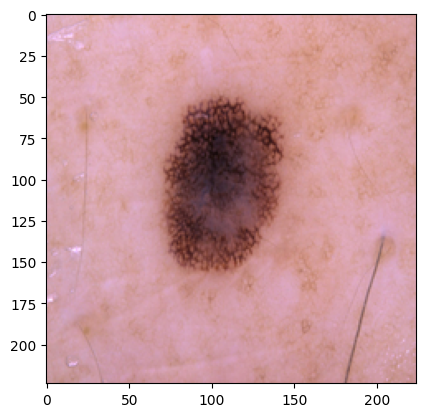

In [ ]:
 import cv2
import numpy as np
from matplotlib.pyplot import imread, imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions, preprocess_input
import os

# Use an absolute path
img_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train/benign/100.jpg'

# Debugging: Print the absolute path
print(f"Loading image from: {img_path}")

# Read the image using OpenCV
img = cv2.imread(img_path)

# Check if the image is successfully loaded
if img is None:
    raise ValueError(f"Error: Unable to load image at path {img_path}")

# Resize the image
img = cv2.resize(img, (100, 100))

# Expand dimensions to fit model input
x = np.expand_dims(img, axis=0)

# Preprocess the input for the model
x = preprocess_input(x)

# Predict using the model
result = model.predict(x)

# Print the result
print((result * 100).astype('int'))

# Display the image using matplotlib
my_image = imread(img_path)
imshow(my_image)


In [ ]:
from tensorflow.keras.models import load_model
loaded_model_imageNet = load_model("model_resnet50.h5")
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [ ]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input

img_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train/malignant/10.jpg'

#img = image.load_img(img_path, target_size=(224, 224))
#x = img.img_to_array(img)

img = cv2.imread(img_path)
img = cv2.resize(img, (100, 100))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)
result = loaded_model_imageNet.predict(x)
print((result*100).astype('int'))

#print('Input image shape:', x.shape)

#my_image = imread(img_path)
#imshow(my_image)


1/1 [==============================] - 1s 1s/step
[[36 63]]


1/1 [==============================] - 0s 104ms/step
[[36 63]]
Input image shape: (1, 100, 100, 3)


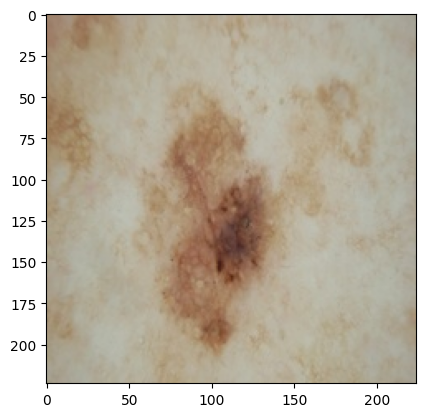

In [ ]:
import cv2
import numpy as np
from matplotlib.pyplot import imread, imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions, preprocess_input
from tensorflow.keras.models import load_model

# Path to the image
img_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train/malignant/10.jpg'

# Load the image using Keras and resize it
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)

# Alternatively, use OpenCV to read and resize the image to a different size
img_cv = cv2.imread(img_path)
if img_cv is None:
    raise ValueError(f"Error: Unable to load image at path {img_path}")
img_cv = cv2.resize(img_cv, (100, 100))

# Expand dimensions to fit model input
x_cv = np.expand_dims(img_cv, axis=0)

# Preprocess the input for the model
x_cv = preprocess_input(x_cv)

# Load the model (ensure the model path is correct)
model_path = '/content/drive/MyDrive/Cancer detection/model.h5'  # Update with the correct path
#loaded_model_imageNet = load_model(model_path)

# Predict using the model
result = loaded_model_imageNet.predict(x_cv)
print((result * 100).astype('int'))

# Print input image shape
print('Input image shape:', x_cv.shape)

# Display the image using matplotlib
my_image = imread(img_path)
imshow(my_image)


1/1 [==============================] - 0s 136ms/step
[[36 63]]


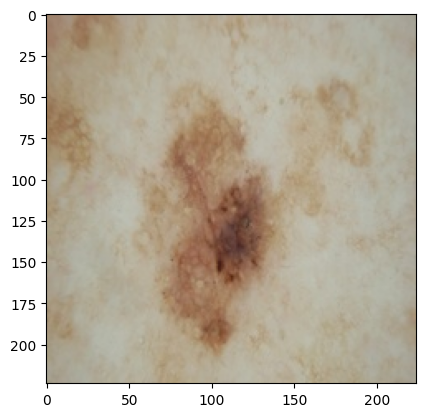

In [ ]:
## the upper part
import cv2
import numpy as np
from matplotlib.pyplot import imread, imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions, preprocess_input
from tensorflow.keras.models import load_model

# Path to the image
img_path = '/content/drive/MyDrive/Cancer detection/archive (2)/train/malignant/10.jpg'

# Check if the image path is correct and the image is loaded
img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Error: Unable to load image at path {img_path}")

# Resize the image
img = cv2.resize(img, (100, 100))

# Expand dimensions to fit model input
x = np.expand_dims(img, axis=0)

# Preprocess the input for the model
x = preprocess_input(x)

# Load the model (ensure the model path is correct)
model_path = '/path/to/your/model.h5'  # Update with the correct path
#loaded_model_imageNet = load_model(model_path)

# Predict using the model
result = loaded_model_imageNet.predict(x)

# Print the result
print((result * 100).astype('int'))

# Optional: Display the image using matplotlib
my_image = imread(img_path)
imshow(my_image)


In [ ]:
p=list((result*100).astype('int'))
pp=list(p[0])
print(pp)

[36, 63]


In [ ]:
print("Largest element is:", max(pp))

Largest element is: 63


In [ ]:
index = pp.index(max(pp))

In [ ]:
name_class=['benign', 'Melignant']

In [ ]:
name_class[index]

'Melignant'

array([[[162, 136, 113],
        [159, 133, 110],
        [156, 130, 107],
        ...,
        [165, 161, 149],
        [162, 160, 147],
        [161, 159, 146]],

       [[161, 135, 112],
        [159, 133, 110],
        [157, 131, 108],
        ...,
        [165, 161, 149],
        [162, 160, 147],
        [161, 159, 146]],

       [[161, 135, 112],
        [159, 133, 110],
        [158, 132, 109],
        ...,
        [164, 162, 149],
        [162, 160, 147],
        [160, 158, 145]],

       ...,

       [[165, 160, 141],
        [168, 163, 144],
        [168, 161, 143],
        ...,
        [168, 162, 148],
        [167, 164, 149],
        [167, 164, 149]],

       [[165, 160, 140],
        [165, 160, 140],
        [165, 158, 139],
        ...,
        [167, 161, 147],
        [168, 162, 148],
        [168, 162, 148]],

       [[164, 159, 137],
        [163, 158, 136],
        [161, 154, 135],
        ...,
        [165, 159, 145],
        [167, 161, 147],
        [167, 161, 147]]], dtype=uint8)
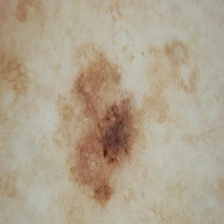

In [ ]:
plt.imread(img_path)

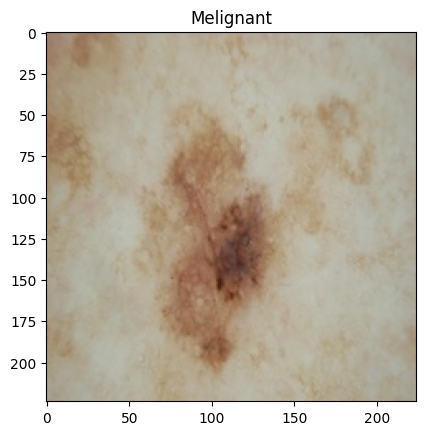

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(img_path)
imgplot = plt.imshow(img)
plt.title(name_class[index])
plt.show()